# Data Visualisation in Pandas

Pandas has a built-in plotting API that wraps Matplotlib, letting us create
charts directly from DataFrames and Series with a single method call. This
module covers everything needed to go from raw data to a presentation-ready
chart without leaving a Jupyter notebook.

**Module overview**

1. **The `plot()` Method** - defaults, axis control, and single vs. multiple
   series
2. **Chart Titles and Axis Labels** - making charts readable for an audience
3. **Colours** - named colours, Hex codes, and colour palettes
4. **Line Styles** - solid, dashed, dash-dot, and dotted lines
5. **Legends and Gridlines** - positioning, hiding, and enabling a grid
6. **Chart Styles** - Seaborn and Matplotlib pre-built style sheets
7. **Subplots and Figure Size** - multiple charts and controlling image size
8. **Bar Charts** - vertical, horizontal, and sorted categorical comparisons

## The `plot()` Method

Calling `.plot()` on a DataFrame produces a line chart by default. Pandas
uses the row index as the X-axis and plots every numeric column as a separate
series on the Y-axis. Non-numeric columns (objects, booleans) are ignored.

**Key points before plotting**

- For a time-series line chart, the index should be the date column. Use
  `.set_index("date")` or the `x=` argument.
- There must be **one row per index value**. Multiple rows sharing the same
  index value produce a zigzag chart with no clear meaning.
- Creating a pivot table before plotting is a reliable way to get data into
  the right shape when working with multiple series.
- In Jupyter, Pandas prints an axis reference below every chart. Add a
  semicolon to the end of the plot call to suppress it.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

### Reading in the data

The `parse_dates` argument converts the date column to `datetime64` on read,
which produces cleaner axis labels and enables time-based filtering with
`.loc`.

In [2]:
transactions = pd.read_csv("https://raw.githubusercontent.com/Okwybobby/NDI-Python-Class/refs/heads/main/transactions.csv", parse_dates=["date"])
transactions.head()

,date,store_nbr,transactions
0,01/01/2013,25,770
1,02/01/2013,1,2111
2,02/01/2013,2,2358
3,02/01/2013,3,3487
4,02/01/2013,4,1922


Calling `.plot()` on the raw DataFrame plots every numeric column. Because
`store_nbr` and `transactions` are both integers, they both appear on the
chart, and without filtering to a single store we have multiple rows per date,
which produces a nonsensical zigzag. We need to set the index and filter
before plotting.

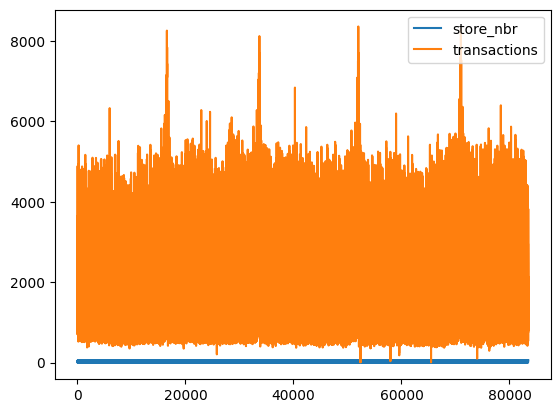

In [3]:

transactions.plot();

Filter to store 44, set `date` as the index, keep only the `transactions`
column, and narrow to 2013 for a clean window. With one row per date and a
datetime index, the line chart makes sense immediately.

In [6]:
transactions["store_nbr"] == 44

,store_nbr
0,False
1,False
2,False
3,False
4,False
...,...
83483,False
83484,False
83485,False
83486,False


In [5]:
transactions.loc[transactions["store_nbr"] == 44]

,date,store_nbr,transactions
38,02/01/2013,44,4821
84,03/01/2013,44,3618
130,04/01/2013,44,4169
176,05/01/2013,44,4921
222,06/01/2013,44,4925
...,...,...,...
83261,11/08/2017,44,4418
83315,12/08/2017,44,4277
83369,13/08/2017,44,4392
83423,14/08/2017,44,4039


In [33]:
transactions["year"] = pd.to_datetime(transactions["date"], format="%d/%m/%Y").dt.year

,store_nbr,transactions,year
date,,,
11/08/2017,44,4418,2017
12/08/2017,44,4277,2017
13/08/2017,44,4392,2017
14/08/2017,44,4039,2017
15/08/2017,44,3815,2017


In [49]:
transactions.head()

,date,store_nbr,transactions,year
0,01/01/2013,25,770,2013
1,02/01/2013,1,2111,2013
2,02/01/2013,2,2358,2013
3,02/01/2013,3,3487,2013
4,02/01/2013,4,1922,2013


<Axes: xlabel='date'>

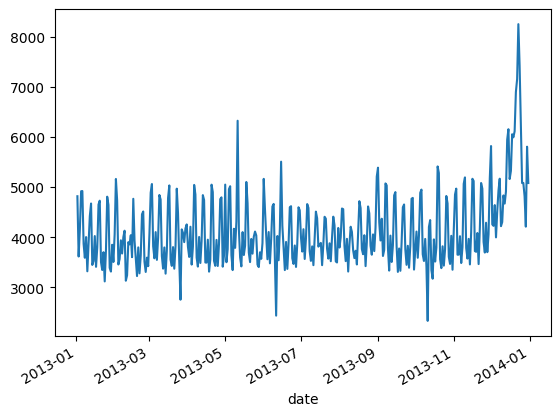

In [55]:
transactions["date"] = pd.to_datetime(transactions["date"], format="%d/%m/%Y")

transactions_44 = (
    transactions
    .loc[transactions["store_nbr"] == 44]
    .set_index("date")
    ["transactions"]
    ["2013"]
)

transactions_44.plot(x = "date", y = "transactions")

Alternatively, keep the date as a regular column and specify `x=` and `y=`
inside the plot call. Both approaches give the same result; pre-filtering is
easier to debug when the chart looks wrong.

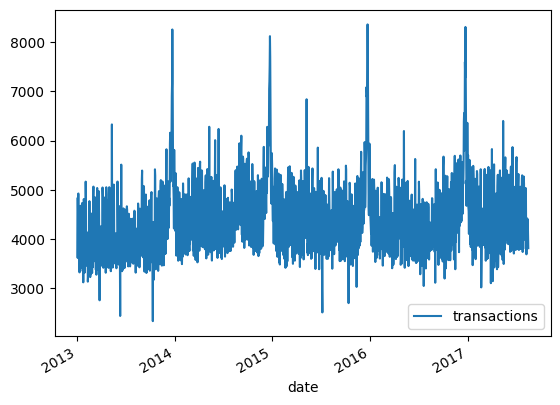

In [54]:
(
    transactions
    .loc[transactions["store_nbr"] == 44]
    .plot(x="date", y="transactions")
);

### Plotting multiple series

Pivot tables are the cleanest way to reshape data into one column per series.
Without specifying `values=`, `pivot_table` creates a MultiIndex for the
column axis, adding an outer level that makes legend labels messy. Calling
`.droplevel(0)` on the column axis removes that outer level.

In [59]:
stores_pivot = (
    transactions
    .loc[transactions["store_nbr"].isin([44, 47])]
    .pivot_table(index="date", columns="store_nbr")
)

# Before droplevel the columns look like: ('transactions', 44), ('transactions', 47)
print(stores_pivot.columns)

MultiIndex([('transactions', 44),
            ('transactions', 47),
            (        'year', 44),
            (        'year', 47)],
           names=[None, 'store_nbr'])


In [57]:
stores_pivot.columns = stores_pivot.columns.droplevel(0)
stores_pivot.head()

store_nbr,44,47,44,47
date,,,,
2013-01-02,4821.0,4161.0,2013.0,2013.0
2013-01-03,3618.0,3660.0,2013.0,2013.0
2013-01-04,4169.0,3915.0,2013.0,2013.0
2013-01-05,4921.0,4764.0,2013.0,2013.0
2013-01-06,4925.0,4935.0,2013.0,2013.0


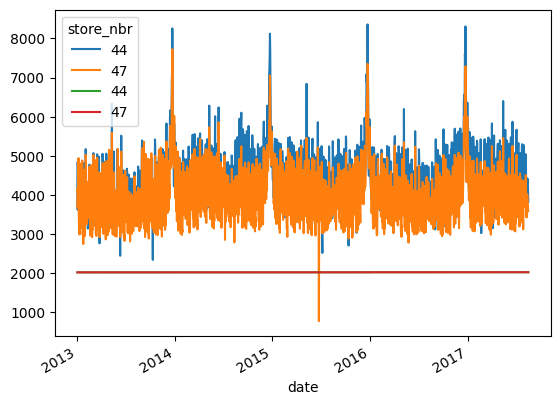

In [58]:
stores_pivot.plot();

## Challenge: Basic Line Chart

An email from Rachel Revenue. Subject: Oil Price Trends.

> Hi there, I do not have a good grasp on the trends in oil prices. There are
> way too many values to understand from table data. Can you plot the oil
> prices with a simple line chart? Also, if you want to, Google "oil price
> decline 2014" to understand the big drop in prices. Thanks.

### Solution: Basic Line Chart

Read in the oil data. The price column is named `dcoilwtico` (the industry
ticker for WTI crude). The date column comes in as an object, so we convert
it to `datetime64` to get proper axis labels.

In [62]:
oil = pd.read_csv("https://raw.githubusercontent.com/Okwybobby/NDI-Python-Class/refs/heads/main/oil.csv")
oil["date"] = oil["date"].astype("datetime64[ns]")
oil.head()
# oil.dtypes

,date,oil_price
0,2013-01-01,NaN
1,2013-01-02,93.14
2,2013-01-03,92.97
3,2013-01-04,93.12
4,2013-01-07,93.20


Set `date` as the index and call `.plot()`. With a datetime index, Pandas
automatically formats the X-axis at the right time granularity.

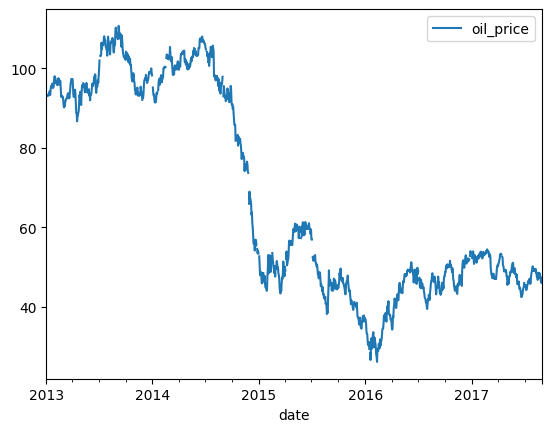

In [63]:
oil.set_index("date").plot();

Filtering by year becomes very convenient once the index is a datetime - pass
the year as a string label directly into `.loc`.

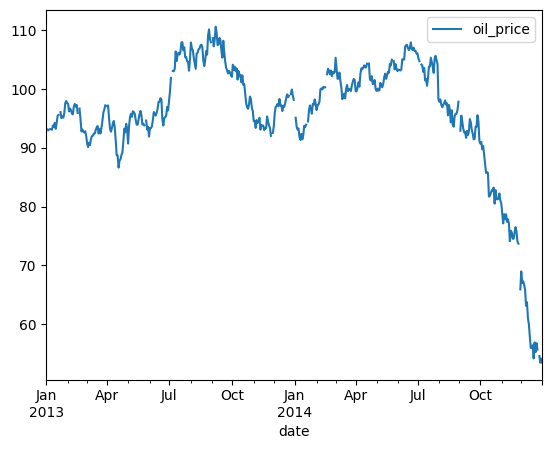

In [64]:
oil.set_index("date").loc["2013":"2014"].plot();

## Chart Titles and Axis Labels

By default, Pandas uses column names as axis and legend labels. These are
rarely presentation-ready. Three arguments handle the most common needs:

- `title=` - the chart title, displayed above the plot area
- `xlabel=` - label for the X-axis
- `ylabel=` - label for the Y-axis

Breaking arguments onto separate lines keeps the call readable as formatting
options accumulate.

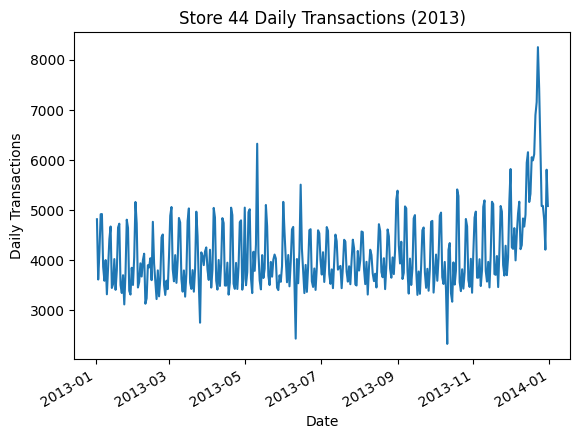

In [65]:
(
    transactions_44
    .plot(
        title="Store 44 Daily Transactions (2013)",
        xlabel="Date",
        ylabel="Daily Transactions",
    )
);

## Challenge: Stylised Line Chart

A follow-up from Rachel Revenue. Subject: Oil Price Presentation.

> Hi there. Thanks for helping me visualise the price trends. Can you format
> it so that it is more suitable for management? Our company tends to use
> darkgrid for the style, but I would also like a chart title, axis labels,
> the line to be black, and the price column renamed to something more
> intuitive. Also, please convert the date column to datetime64 for better
> X-axis labels. Thanks.

### Solution: Stylised Line Chart

Import Seaborn and set the style before any plotting. The style persists for
all charts produced below that line in the notebook.

In [66]:
import seaborn as sns

sns.set_style("darkgrid")

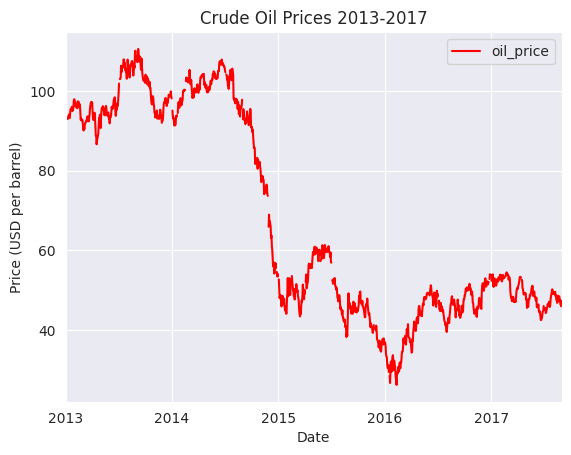

In [71]:
(
    oil
    .set_index("date")
    .plot(
        title="Crude Oil Prices 2013-2017",
        xlabel="Date",
        ylabel="Price (USD per barrel)",
        color="#FF0000",
    )
);

## Colours

The `color=` argument (shorthand: `c=`) controls the line or bar colour.
Matplotlib recognises common colour names such as `"black"`, `"red"`,
`"green"`, and `"blue"`, as well as Hex codes for any specific shade.

For multiple series, pass a **list** of colours in the same order as the
columns in the DataFrame.

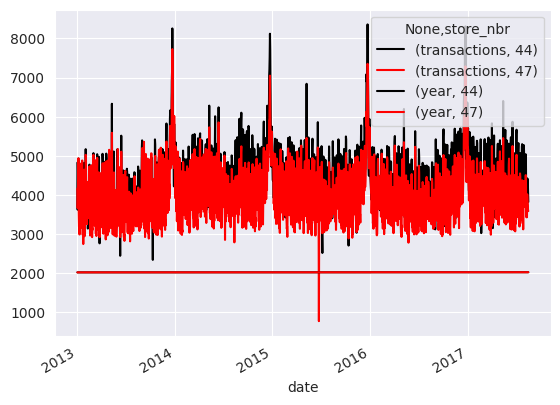

In [72]:
# Named colours - one per series
stores_pivot.plot(color=["black", "red"]);

Hex codes give precise control over shade. Copy them from a colour picker
tool such as Google's colour picker, or from a company style guide.

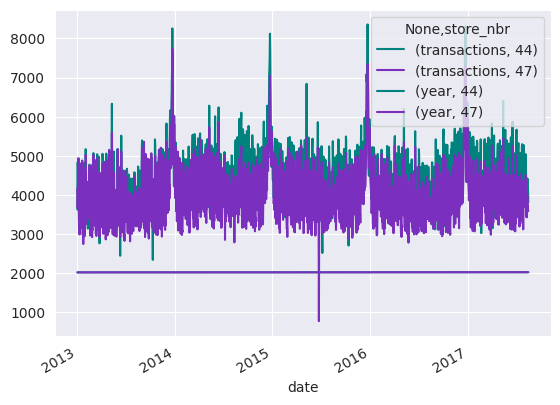

In [73]:
# Hex codes for teal and purple
stores_pivot.plot(color=["#00827F", "#7B2FBE"]);

The `colormap=` argument sets a colour palette that cycles through colours
automatically. Qualitative colormaps such as `"tab10"` or `"Pastel2"` work
best for line charts where each series should be visually distinct.

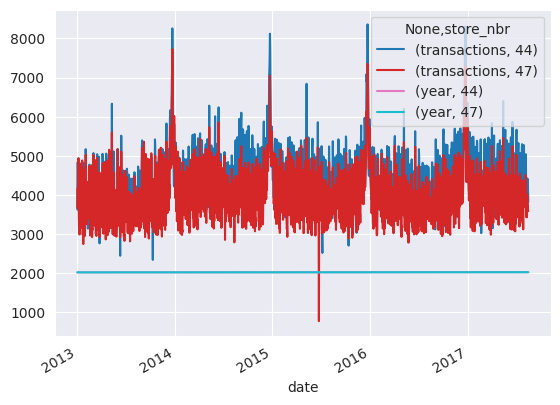

In [74]:
stores_pivot.plot(colormap="tab10");

The `alpha=` argument controls transparency on a scale from 0 (invisible) to
1 (fully solid). Useful when series overlap and would otherwise obscure each
other.

<Axes: xlabel='date'>

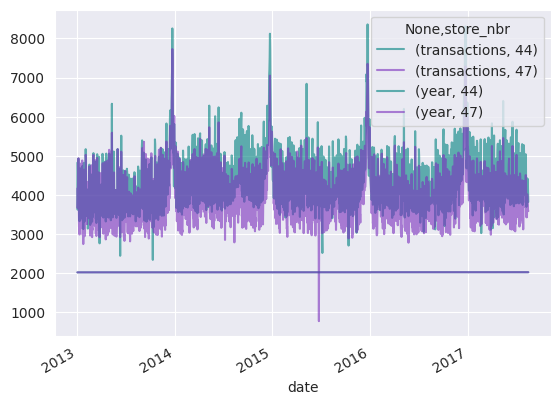

In [78]:
stores_pivot.plot(color=["#00827F", "#7B2FBE"], alpha=0.6)

## Line Styles

The default line style is solid. Use the `style=` argument to change it. For
multiple series, pass a list in column order. This adds a visual distinction
that survives printing in black and white.

Common styles: `"solid"` (default), `"dashed"`, `"dashdot"`, `"dotted"`.

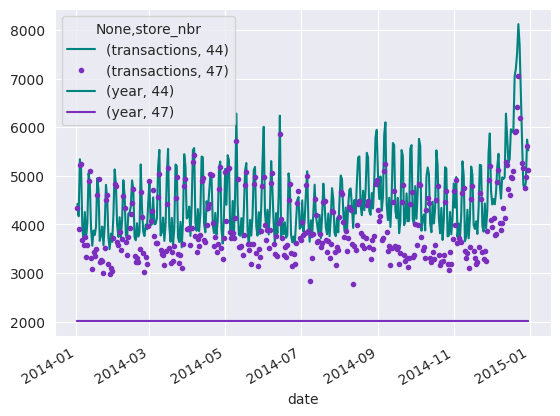

In [82]:
stores_2014 = stores_pivot.loc["2014"]

stores_2014.plot(
    color=["#00827F", "#7B2FBE"],
    style=["-", "."],
);

## Legends and Gridlines

By default, Pandas places the legend in the best available white space. To
control placement, chain the `.legend()` method to the plot call and pass a
`loc=` string such as `"upper right"`, `"center left"`, or `"lower center"`.

For finer control, pass `bbox_to_anchor=(x, y)`. The coordinates use the
chart area as the unit square: `(0, 0)` is bottom-left and `(1, 1)` is
top-right. Values above 1 push the legend outside the chart boundary.

- `legend=False` - removes the legend entirely
- `grid=True` - switches on gridlines

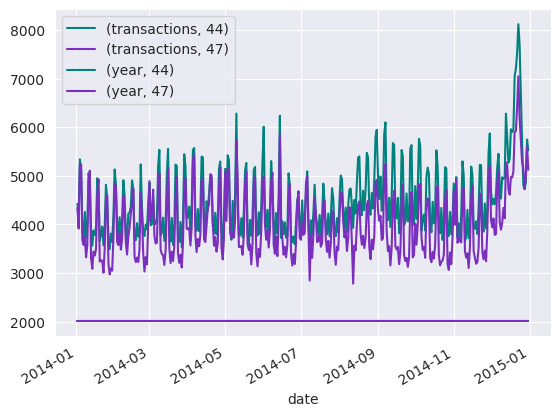

In [85]:
# Legend repositioned to upper right, gridlines enabled
stores_2014.plot(
    color=["#00827F", "#7B2FBE"],
    grid=True,
).legend(loc="upper left");

Push the legend outside the chart area with `bbox_to_anchor`.

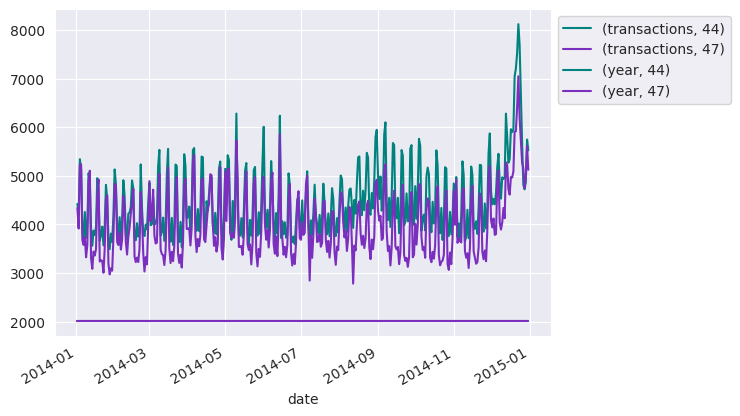

In [86]:
stores_2014.plot(
    color=["#00827F", "#7B2FBE"],
).legend(bbox_to_anchor=(1, 1));

Remove the legend entirely when it would obscure too much data.

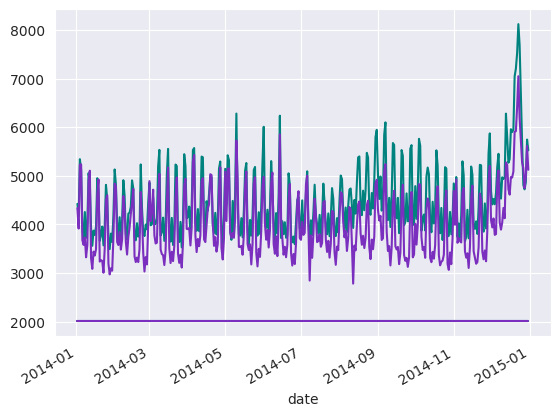

In [87]:
stores_2014.plot(
    color=["#00827F", "#7B2FBE"],
    legend=False,
);

## Chart Styles

Matplotlib and Seaborn ship with pre-built style sheets that set defaults for
fonts, background colours, and gridlines without manual configuration. Set a
style once at the top of the notebook and it applies to every chart below.

**Seaborn styles** (set with `sns.set_style()`):
`"darkgrid"`, `"whitegrid"`, `"dark"`, `"white"`, `"ticks"`

**Matplotlib styles** (set with `matplotlib.style.use()`):
`"fivethirtyeight"`, `"ggplot"`, `"bmh"`, and many others

Any argument passed directly to `.plot()` overrides the style-sheet default
for that property, so you can always customise on top of a pre-built style.

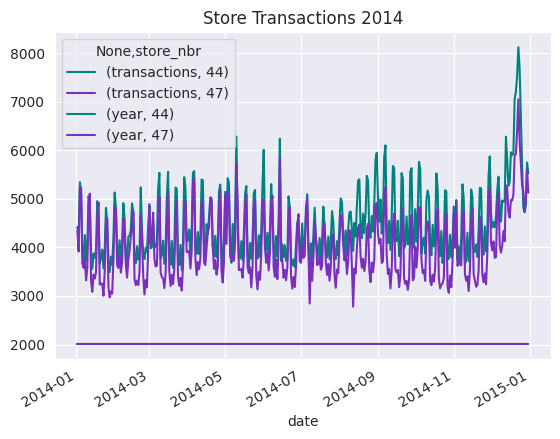

In [90]:
# Seaborn darkgrid - already set above; shown here for reference
sns.set_style("darkgrid")

stores_2014.plot(
    title="Store Transactions 2014",
    color=["#00827F", "#7B2FBE"],
);

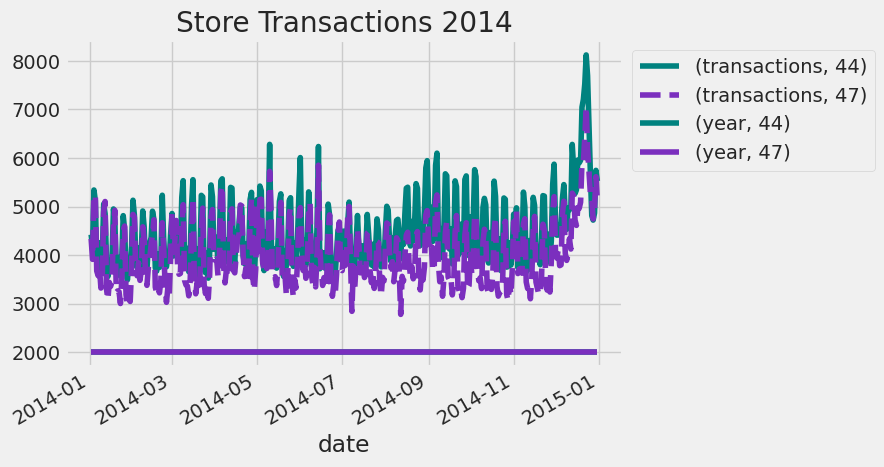

In [92]:
# Switch to a Matplotlib style
import matplotlib

matplotlib.style.use("fivethirtyeight")

stores_2014.plot(
    title="Store Transactions 2014",
    color=["#00827F", "#7B2FBE"],
    style=["-", "--"],
).legend(bbox_to_anchor=(1, 1))

Reset to Seaborn darkgrid for the rest of the notebook.

In [93]:
sns.set_style("darkgrid")

## Subplots and Figure Size

By default, all series in a DataFrame are drawn on a single chart area.
Setting `subplots=True` creates a separate chart for each numeric column.

- `layout=(rows, cols)` - arrange the subplots in a grid. The product of
  rows and columns must equal the number of series.
- `sharey=True` - all subplots share the same Y-axis scale. Strongly
  recommended when comparing similar series; mismatched Y-axes make a smaller
  series look falsely comparable to a larger one.
- `sharex=True` - shared X-axis (default when subplots are in a column).
- `title=` - accepts a **list** of strings, one per subplot in order.

`figsize=(width, height)` controls the physical size of the image in inches.
The default is 6.4 x 4.8 inches. Larger figures give dense data more space
and produce higher-resolution images for presentations.

Build a sales-by-category pivot from the retail data to demonstrate a 2x2
subplot layout. We filter to a single store and four product families so
each family becomes one series, closely matching the kind of breakdown a
sales analyst would typically visualise.

In [94]:
retail = pd.read_csv("https://raw.githubusercontent.com/Okwybobby/NDI-Python-Class/refs/heads/main/retail_2016_2017.csv", parse_dates=["date"])
retail.head()

,id,date,store_nbr,family,sales,onpromotion
0,1945944,2016-01-01,1,AUTOMOTIVE,0.0,0
1,1945945,2016-01-01,1,BABY CARE,0.0,0
2,1945946,2016-01-01,1,BEAUTY,0.0,0
3,1945947,2016-01-01,1,BEVERAGES,0.0,0
4,1945948,2016-01-01,1,BOOKS,0.0,0


In [95]:
families = ["BEVERAGES", "LIQUOR,WINE,BEER", "GROCERY I", "PREPARED FOODS"]

sales_df = (
    retail
    .loc[
        (retail["store_nbr"] == 44) &
        (retail["family"].isin(families))
    ]
    .pivot_table(index="date", columns="family", values="sales")
)
sales_df.head()

family,BEVERAGES,GROCERY I,"LIQUOR,WINE,BEER",PREPARED FOODS
date,,,,
2016-01-01,0.0,0.0,0.0,0.00000
2016-01-02,13006.0,13496.0,431.0,600.83203
2016-01-03,18421.0,16399.0,0.0,583.43300
2016-01-04,11911.0,11716.0,261.0,539.39197
2016-01-05,9361.0,9804.0,299.0,532.81600


Without `sharey=True`, the Y-axis on each subplot scales independently.
Grocery I and Beverages appear comparable to Prepared Foods, but the scales
are very different - this is misleading.

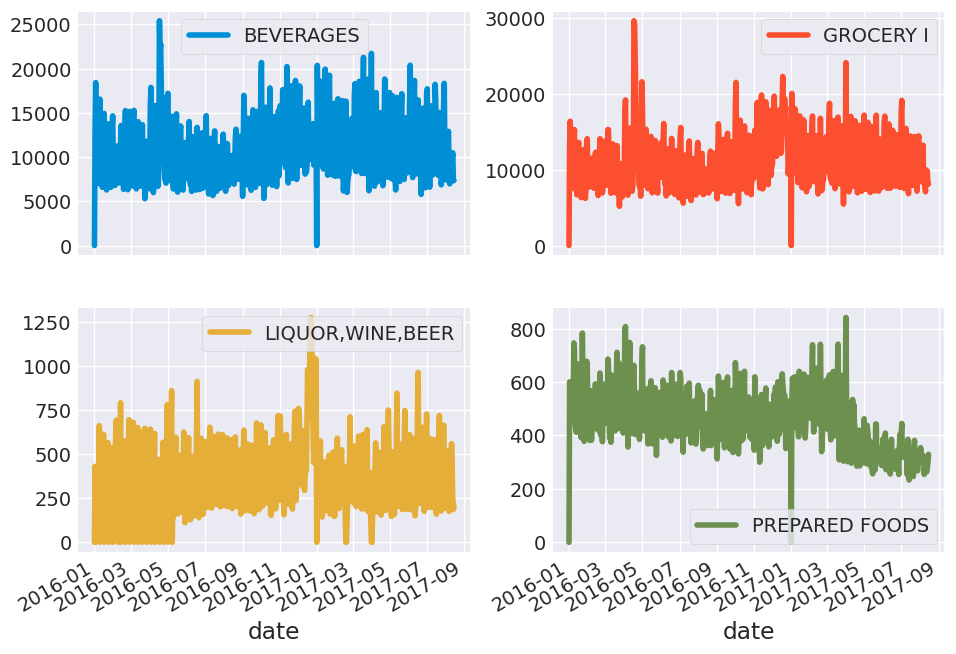

In [96]:
sales_df.plot(
    subplots=True,
    layout=(2, 2),
    figsize=(10, 8),
);

With `sharey=True`, the shared Y-axis immediately reveals that Grocery I
dominates all other categories. This is one of the most important arguments
to use whenever comparing related series in subplots.

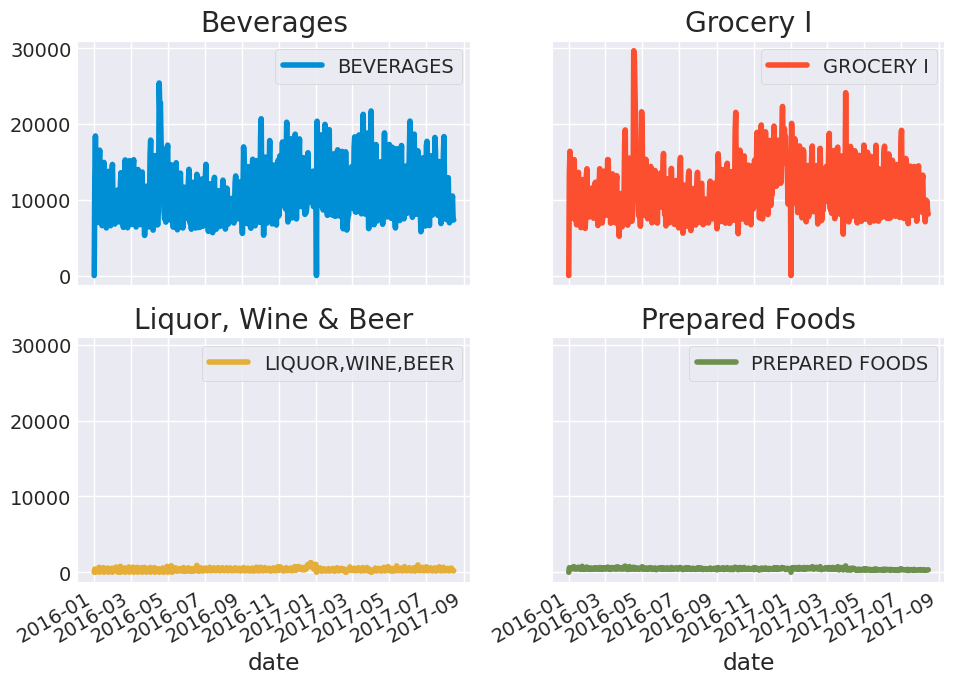

In [100]:
sales_df.plot(
    subplots=True,
    layout=(2, 2),
    sharey=True,
    figsize=(10, 8),
    title=["Beverages", "Grocery I",  "Liquor, Wine & Beer", "Prepared Foods"],
);

## Challenge: Subplots

An email from Joey Justin Time, our logistics clerk. Subject: Transactions by
Store.

> Hi there, nice to meet you. Can you filter the transactions table to stores
> 1, 2, 3, and 4? Then pivot it so we have dates as rows and store numbers as
> columns. Then create a two-by-two plot of the transactions for each store as
> a line chart. Make sure they share a Y-axis and consider making the figure
> a bit larger. Which stores have the most transactions? Do they spike at
> similar times? Thanks.

### Solution: Subplots

Build the pivot table in one chained expression. Filter to the four stores,
pivot, then drop the outer column level.

In [105]:
stores_1234 = (
    pd.read_csv("https://raw.githubusercontent.com/Okwybobby/NDI-Python-Class/refs/heads/main/transactions.csv", parse_dates=["date"])
    .loc[lambda df: df["store_nbr"].isin([1, 2, 3, 4])]
    .pivot_table(index="date", columns="store_nbr")
)
stores_1234.columns = stores_1234.columns.droplevel(0)
stores_1234.head()

store_nbr,1,2,3,4
date,,,,
01/02/2013,1806.0,1977.0,3230.0,1520.0
01/02/2014,1344.0,2183.0,3774.0,1844.0
01/02/2015,502.0,2159.0,3683.0,1929.0
01/02/2016,1787.0,1920.0,3220.0,1517.0
01/02/2017,1900.0,2083.0,3347.0,1467.0


Plot the four series in a 2x2 grid with a shared Y-axis. Store 3 clearly
outperforms the others because the shared axis keeps the scales comparable.
All stores show similar spikes around holiday periods.

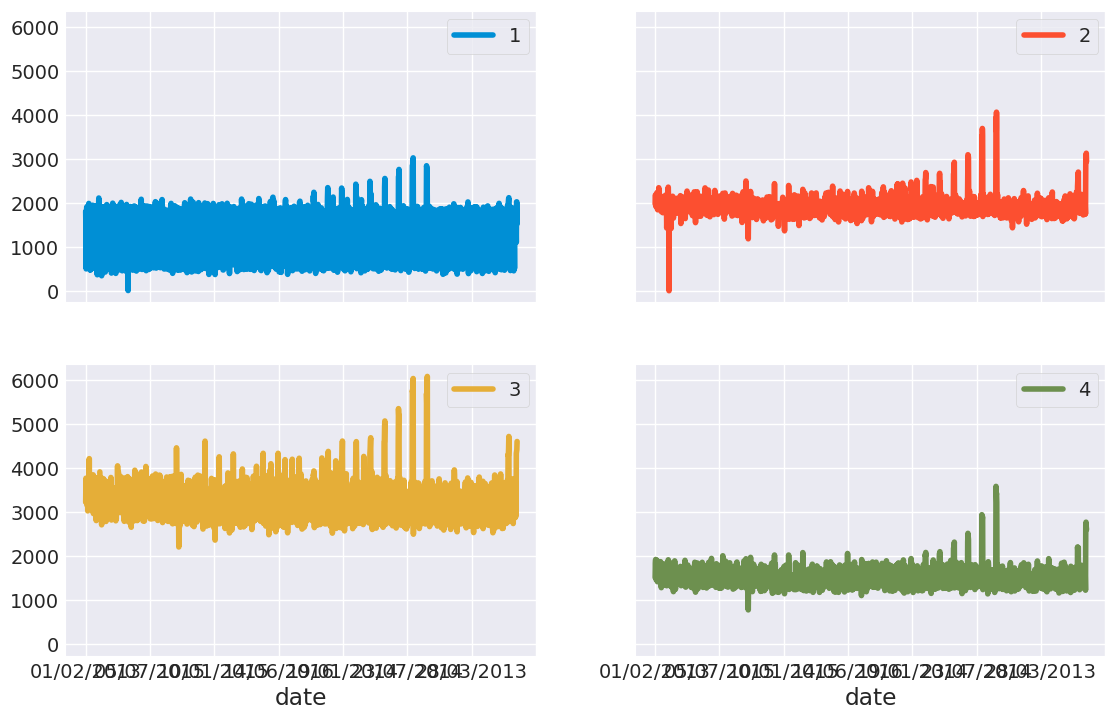

In [107]:
stores_1234.plot(
    subplots=True,
    layout=(2, 2),
    sharey=True,
    figsize=(12, 8),
);

## Bar Charts

Bar charts are the right choice for comparing values across categories. A line
implies continuity between adjacent points; bars are better when there is no
meaningful connection between categories.

Specify the chart type with `.plot.bar()` or `.plot.barh()` for a horizontal
bar chart. This is preferred over passing `kind="bar"` inside `.plot()`
because it makes the chart type explicit and keeps the call clean.

**Sorting tip for horizontal bar charts**: to get the largest bar at the top,
sort values in ascending order before calling `.plot.barh()`. The same quirk
exists in Excel.

Aggregate total transactions by store number, then plot as a vertical bar chart.

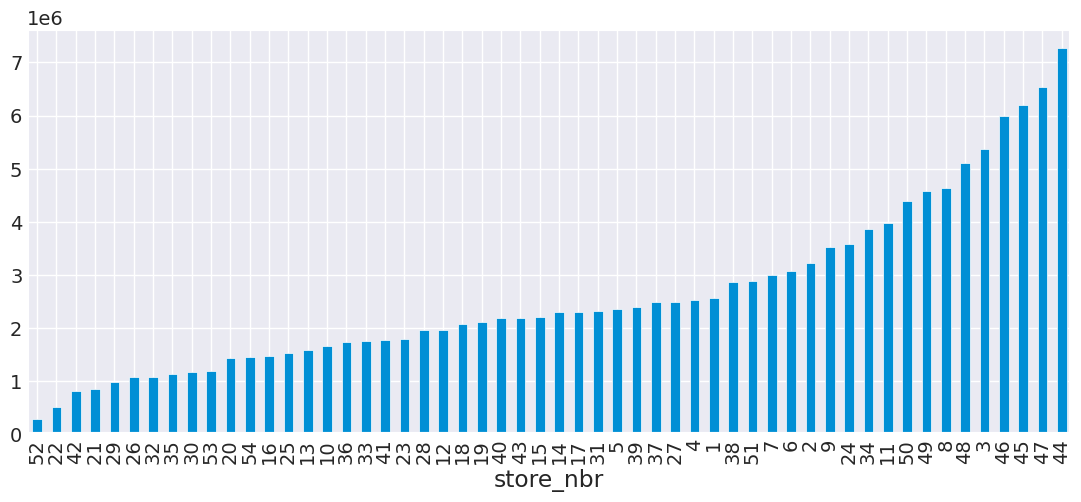

In [108]:
store_totals = (
    transactions
    .groupby("store_nbr")["transactions"]
    .sum()
    .sort_values()
)

store_totals.plot.bar(figsize=(12, 5), legend=False);

Filter to stores in the 40s for a cleaner comparison and sort so the ranking
reads clearly from the chart.

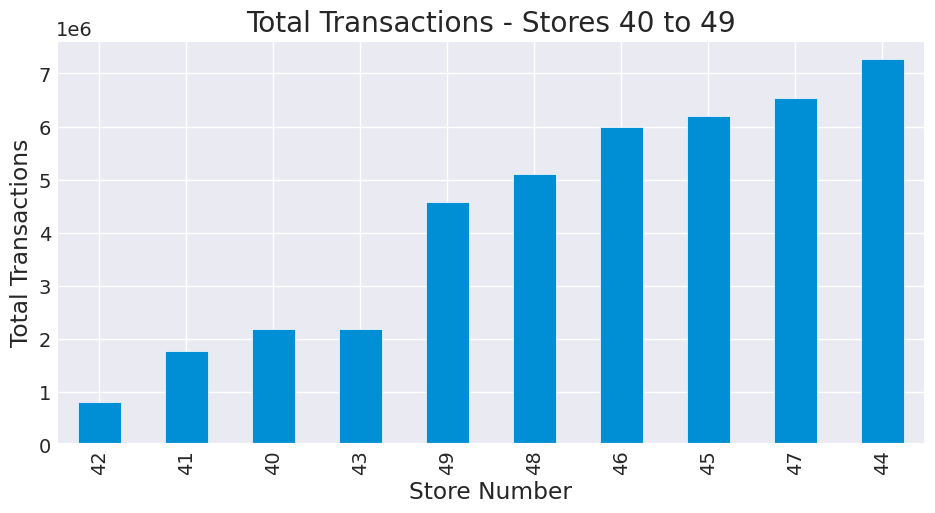

In [109]:
stores_40s = (
    transactions
    .loc[transactions["store_nbr"].between(40, 49)]
    .groupby("store_nbr")["transactions"]
    .sum()
    .sort_values()
)

stores_40s.plot.bar(
    title="Total Transactions - Stores 40 to 49",
    xlabel="Store Number",
    ylabel="Total Transactions",
    figsize=(10, 5),
    legend=False,
);

A horizontal bar chart. Because we sorted in ascending order, the largest bar
sits at the top, which is the natural reading direction for a ranked list.

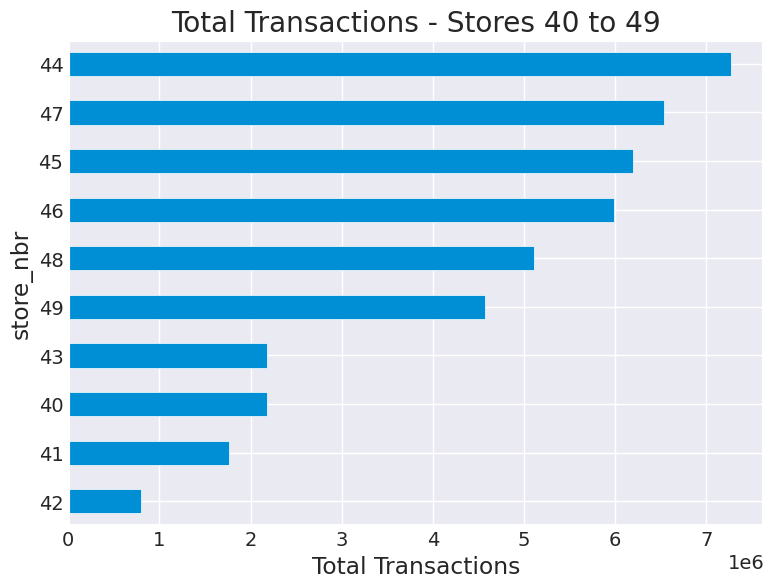

In [110]:
stores_40s.plot.barh(
    title="Total Transactions - Stores 40 to 49",
    xlabel="Total Transactions",
    figsize=(8, 6),
    legend=False,
);

## What Comes Next

With the Matplotlib API, chart types, formatting, and subplots covered, the
next lessons look at pie charts, scatter plots, histograms, and saving charts
to image files, before a look at the broader Python visualisation ecosystem
including Plotly and the full Seaborn library.